# ТК 3-4. Классификация вин
Хорошее вино — `quality >= 7` (класс 1), остальное — некачественное (класс 0). Обучаем логистическую регрессию, проверяем на неизвестных винах: Accuracy, Precision, Recall + confusion matrix.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("winequality-red.csv")
df["good"] = (df["quality"] >= 7).astype(int)
print(df["good"].value_counts())
print(f"Доля хороших: {df['good'].mean():.1%} (классы несбалансированы)")

good
0    1382
1     217
Name: count, dtype: int64
Доля хороших: 13.6% (классы несбалансированы)


## Обучение: split + масштабирование + модель

Признаки — все 11 физико-химических показателей, ответ — `good`. Делим stratify 80/20, масштабируем `StandardScaler`, обучаем `LogisticRegression` (как в примере занятия).

In [2]:
FEATURES = [c for c in df.columns if c not in ("quality", "good")]
X = df[FEATURES].to_numpy(dtype=float)
y = df["good"].to_numpy(dtype=int)

# 80% учимся, 20% проверяемся; stratify сохраняет долю хороших вин
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабируем: обучаем scaler только на train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_s, y_train)
print("Модель обучена.")

Модель обучена.


## Уравнение гиперплоскости (граница классов)

In [3]:
w = model.coef_[0]
b = model.intercept_[0]
for name, wi in zip(FEATURES, w):
    print(f"{name:22s}: {wi:+.4f}")
print(f"Смещение b: {b:+.4f}")
print("Правило: w·z + b > 0 → Хорошее (1), иначе → Некачественное (0)")

fixed acidity         : +0.2177
volatile acidity      : -0.4257
citric acid           : +0.1054
residual sugar        : +0.2387
chlorides             : -0.3678
free sulfur dioxide   : +0.2773
total sulfur dioxide  : -0.8174
density               : -0.2755
pH                    : -0.1517
sulphates             : +0.6111
alcohol               : +0.8944
Смещение b: -2.8064
Правило: w·z + b > 0 → Хорошее (1), иначе → Некачественное (0)


## Метрики и confusion matrix (проверка на тесте)

Accuracy  = 0.8938
Precision = 0.6957
Recall    = 0.3721
Confusion matrix (строки=true, столбцы=предсказание):
[[270   7]
 [ 27  16]]


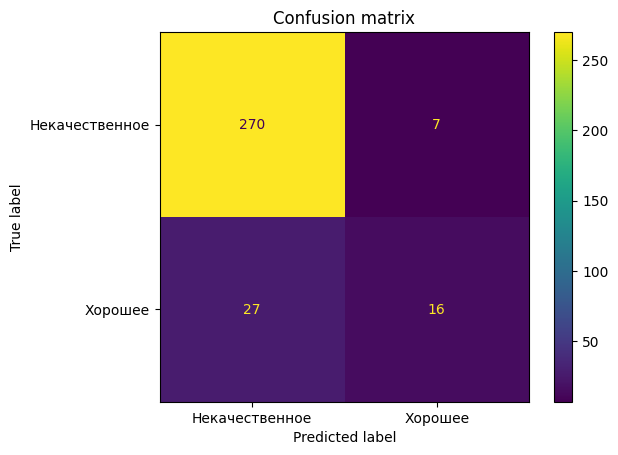

In [4]:
y_pred = model.predict(X_test_s)
print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (строки=true, столбцы=предсказание):")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Некачественное", "Хорошее"]).plot()
plt.title("Confusion matrix")
plt.show()

## Неизвестные вина: классифицируем 5 штук

Берем 5 вин из тестовой выборки, «забываем» их метки и классифицируем как неизвестные: выводим предсказанный класс и вероятность быть хорошим.

In [5]:
rng = np.random.RandomState(42)
idx = rng.choice(len(X_test), size=5, replace=False)
unknown_s = scaler.transform(X_test[idx])
pred_u = model.predict(unknown_s)
proba_u = model.predict_proba(unknown_s)[:, 1]

out = pd.DataFrame(X_test[idx], columns=FEATURES)
out["Прогноз"] = np.where(pred_u == 1, "Хорошее", "Некачественное")
out["P(хорошее)"] = np.round(proba_u, 3)
print(out.to_string())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol         Прогноз  P(хорошее)
0            9.9              0.72         0.55             1.7      0.136                 24.0                  52.0  0.99752  3.35       0.94     10.0  Некачественное       0.053
1            6.9              0.56         0.03             1.5      0.086                 36.0                  46.0  0.99522  3.53       0.57     10.6  Некачественное       0.046
2            7.0              0.60         0.30             4.5      0.068                 20.0                 110.0  0.99914  3.30       1.17     10.2  Некачественное       0.054
3            5.6              0.31         0.78            13.9      0.074                 23.0                  92.0  0.99677  3.39       0.48     10.5  Некачественное       0.124
4            7.9              0.32         0.51             1.8      0.341                 17.0

**Выводы:** Accuracy 0.89, Precision 0.70, Recall 0.37. Слову «хорошее» верить можно, но половину хороших вин модель пропускает — хороших всего 13.6% (дисбаланс). Матрица: 270 плохих угаданы, 16 хороших найдены. Сильнее всех за «хорошее» — alcohol и sulphates, против — total sulfur dioxide.